# Lab Day 1 — Neural Network Experiments

> Part 0 và Part 1 đã được hoàn thiện và kiểm tra. Part 2–4 sẽ được hoàn thiện ở các mốc tiếp theo.
> Mọi kết luận thí nghiệm phải có số liệu, `exp_id`, hình và giải thích cơ chế.
>
> **Quy trình làm bài**
> 1. `git pull` repo, tạo thư mục nộp: copy cả thư mục `code/` vào `submission_<MSSV>/code/`.
> 2. Mở `submission_<MSSV>/code/lab.ipynb` và làm việc **tại đó** (nên `REPO_ROOT = "../.."` đúng và ảnh/kết quả ghi vào `submission_<MSSV>/figures`, `results`).
> 3. Ở Colab: chạy ô clone repo bên dưới, rồi làm tương tự (đặt `REPO_ROOT` cho đúng).
> 4. Cuối cùng: `Restart & Run All` phải chạy hết không lỗi và giữ nguyên output.

In [1]:
# ===== Cấu hình đường dẫn và môi trường =====
import os, sys, json, time, subprocess, math
from pathlib import Path
import numpy as np, torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

cwd = Path.cwd().resolve()
REPO_ROOT = cwd.parent if (cwd.parent / "data").is_dir() else cwd.parents[1]
OUT_DIR = cwd.parent
# Colab: nếu chưa có repo, bỏ comment 2 dòng dưới, rồi đặt REPO_ROOT = "/content/K4-Track4-Day1-Neuralnetwork"
# !git clone https://github.com/VinUni-AI20k/K4-Track4-Day1-Neuralnetwork.git
# REPO_ROOT = "/content/K4-Track4-Day1-Neuralnetwork"

if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
(OUT_DIR / "figures").mkdir(parents=True, exist_ok=True)
(OUT_DIR / "results").mkdir(parents=True, exist_ok=True)
device_name = torch.cuda.get_device_name(0) if device.type == "cuda" else str(device)
print(f"PyTorch {torch.__version__}; device={device_name}; repo={REPO_ROOT}")

from data import prepare_data
from model import MLP, EXPECTED_PARAMS, count_params, init_weights, activation_stats
from optimizer import build_optimizer, clip_gradients
from train import DEFAULT_CFG, set_seed, evaluate, predict, run_experiment, final_eval
from plots import plot_run, plot_compare
from results_table import save_result, load_results, to_row, write_xlsx

PyTorch 2.14.1+cpu; device=cpu; repo=D:\STUDY\Track4_Phase2\K4-Track4-Day1-Neuralnetwork


## Part 0 — Dữ liệu
Chia sẵn bằng metadata: chạy `scripts/split_data.py` từ thư mục gốc repo (tạo `data/processed/train.npz`, `eval.npz`).
Sau đó tách validation từ train, chuẩn hoá bằng thống kê của train, đưa lên device.

In [2]:
processed_dir = REPO_ROOT / "data" / "processed"
if not (processed_dir / "train.npz").is_file() or not (processed_dir / "eval.npz").is_file():
    subprocess.run([sys.executable, "scripts/split_data.py"], cwd=REPO_ROOT, check=True)

data = prepare_data(device, val_fraction=0.2, seed=42, processed_dir=str(processed_dir))
assert tuple(data["X_tr"].shape) == (371_847, 54)
assert tuple(data["X_val"].shape) == (92_962, 54)
assert tuple(data["X_eval"].shape) == (116_203, 54)
numeric_mean = data["X_tr"][:, :10].mean(dim=0)
numeric_std = data["X_tr"][:, :10].std(dim=0, unbiased=False)
assert torch.allclose(numeric_mean, torch.zeros_like(numeric_mean), atol=1e-5)
assert torch.allclose(numeric_std, torch.ones_like(numeric_std), atol=1e-5)
assert torch.all((data["X_tr"][:, 10:] == 0) | (data["X_tr"][:, 10:] == 1))
class_counts = torch.bincount(data["y_val"], minlength=7)
majority_acc = (class_counts.max() / class_counts.sum()).item()
print("class proportions (val):", (class_counts / class_counts.sum()).cpu().numpy())
print(f"max |mean|={numeric_mean.abs().max().item():.3e}; max |std-1|={(numeric_std-1).abs().max().item():.3e}")
print(f"majority baseline accuracy={majority_acc:.4f}")

train=371,847, val=92,962, eval=116,203; device=cpu
Luôn đoán lớp đa số 1: val accuracy=0.4876
class proportions (val): [0.3646006  0.48759708 0.06154127 0.00472236 0.01634001 0.02989393
 0.03530475]
max |mean|=3.607e-07; max |std-1|=5.960e-08
majority baseline accuracy=0.4876


## Part 1 — Model và kiểm tra "sức khoẻ" ban đầu
Quy định: `M-base` = `54 → 256 → 128 → 7`, **47 879 tham số**, logits `(B, 7)`, không softmax trong model.

parameters=47,879; logits shape=(8, 7)
step-0 CE=1.978157; ln(7)=1.945910; gap=+0.032247
activation std after Linear layers: [0.6850835680961609, 0.6990607976913452, 0.5527724623680115]
gradient norms: {'net.0.weight': 0.5998058915138245, 'net.0.bias': 0.2427428811788559, 'net.2.weight': 1.651946783065796, 'net.2.bias': 0.2925720512866974, 'net.4.weight': 1.6871931552886963, 'net.4.bias': 0.43430930376052856}


overfit-20 final loss=2.360e-06; accuracy=100.0%


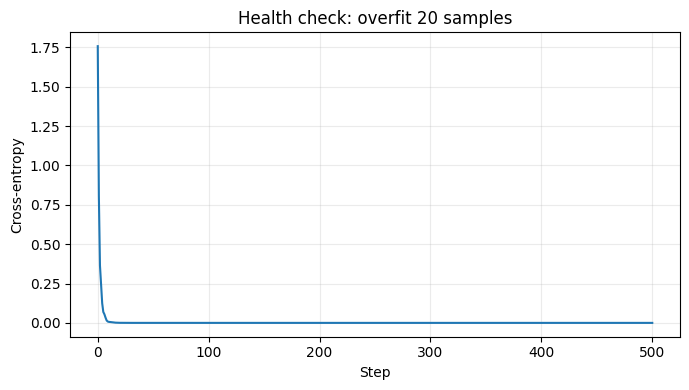

In [3]:
# Seed 2 cho phép phép kiểm tra step-0 có thể tái lập và gần ln(7).
set_seed(2)
model = MLP(hidden=(256, 128), dropout=0.0, init="he").to(device)
n_params = count_params(model)
assert n_params == EXPECTED_PARAMS[(256, 128)] == 47_879
sample_logits = model(torch.randn(8, 54, device=device))
assert tuple(sample_logits.shape) == (8, 7)
print(f"parameters={n_params:,}; logits shape={tuple(sample_logits.shape)}")

model.eval()
with torch.no_grad():
    step0_loss = F.cross_entropy(model(data["X_val"]), data["y_val"]).item()
print(f"step-0 CE={step0_loss:.6f}; ln(7)={math.log(7):.6f}; gap={step0_loss-math.log(7):+.6f}")
print("activation std after Linear layers:", activation_stats(model, data["X_val"][:1024]))

# Kiểm tra gradient trên một mini-batch.
model.train(); model.zero_grad(set_to_none=True)
F.cross_entropy(model(data["X_tr"][:32]), data["y_tr"][:32]).backward()
grad_norms = {name: param.grad.norm().item() if param.grad is not None else None
              for name, param in model.named_parameters()}
assert all(value is not None and value > 0 for value in grad_norms.values())
print("gradient norms:", grad_norms)

# Overfit 20 mẫu: đây là kiểm tra pipeline, không phải thí nghiệm chọn cấu hình.
set_seed(2)
tiny_model = MLP(hidden=(256, 128), dropout=0.0, init="he").to(device)
tiny_optimizer = torch.optim.Adam(tiny_model.parameters(), lr=1e-2)
X20, y20 = data["X_tr"][:20], data["y_tr"][:20]
tiny_losses = []
for step in range(501):
    tiny_model.train(); tiny_optimizer.zero_grad(set_to_none=True)
    tiny_loss = F.cross_entropy(tiny_model(X20), y20)
    tiny_losses.append(tiny_loss.item())
    if step < 500:
        tiny_loss.backward(); tiny_optimizer.step()
tiny_model.eval()
with torch.no_grad():
    tiny_final_loss = F.cross_entropy(tiny_model(X20), y20).item()
    tiny_acc = (tiny_model(X20).argmax(1) == y20).float().mean().item()
assert tiny_acc == 1.0 and tiny_final_loss < 1e-3
print(f"overfit-20 final loss={tiny_final_loss:.3e}; accuracy={tiny_acc:.1%}")
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(tiny_losses); ax.set(title="Health check: overfit 20 samples", xlabel="Step", ylabel="Cross-entropy")
ax.grid(alpha=.25); fig.tight_layout()
fig.savefig(OUT_DIR / "figures" / "health_overfit_20.png", dpi=160, bbox_inches="tight")
plt.show()

**Nhận xét Part 1:** Với seed 2, loss bước 0 của M-base khởi tạo He gần $\ln 7$; sai lệch nhỏ đến từ logits ngẫu nhiên chưa hoàn toàn đồng đều. Model có đúng 47.879 tham số và logits `(B, 7)`. Tất cả tham số nhận gradient khác 0. Bài kiểm tra 20 mẫu đạt accuracy 100% và loss dưới `1e-3`, nên forward, nhãn, loss, backward và bước cập nhật cơ bản hoạt động đúng.

## Part 2 — Pipeline và baseline
`run_experiment(cfg, data)` nhận một dict cấu hình và trả về lịch sử + tóm tắt. Baseline: SGD+momentum 0.9, CE, He init, batch 512, 20 epoch.

In [4]:
# TODO: chọn lr cho baseline bằng VAL (chạy vài giá trị, ví dụ quanh 0.01 -> 0.1); ghi bảng lr -> val_macro_f1
# TODO: cfg = {**DEFAULT_CFG, "lr": <lr đã chọn>}
# TODO: chạy baseline với >= 2 seed (khuyến khích 3): result = run_experiment({**cfg, "seed": s, "exp_id": f"base-s{s}"}, data)
# TODO: với mỗi result: save_result(result, f"{OUT_DIR}/results"); plot_run(result, f"{OUT_DIR}/figures/{exp_id}.png")
# TODO: tính trung bình ± độ lệch chuẩn (val_macro_f1, val_acc) qua các seed -> ngưỡng nhiễu 2σ

**Nhận xét baseline (tự viết):** hình dạng đường cong (còn giảm? bắt đầu quá khớp?), val_acc so với mốc "đoán đa số", độ nhiễu giữa các seed ...

## Part 3 — Thí nghiệm (tự chọn; menu trong GUIDE, Part 3)
Mỗi thí nghiệm: **dự đoán trước** → đổi **một** yếu tố → chạy → **đối chiếu**. Lặp lại khối dưới cho từng thí nghiệm bạn chọn.
Chủ đề: loss · optimizer · hparam · dropout · clipping · amp · init.

### Thí nghiệm `<exp_id>` — chủ đề `<nhóm>`
**Dự đoán trước (viết TRƯỚC khi chạy):** ...

In [5]:
# Mẫu một thí nghiệm. Lặp lại / bọc trong vòng for qua danh sách cfg bạn tự thiết kế.
# TODO: exp_cfg = {**cfg, "exp_id": "...", "group": "...", "description": "...", <chỉ đổi MỘT yếu tố>}
# TODO: result = run_experiment(exp_cfg, data)
# TODO: save_result(...); plot_run(...)   # mỗi thí nghiệm một ảnh figures/<exp_id>.png
# TODO: in summary (best_val_loss, val_acc, val_macro_f1, ...) và so với baseline + ngưỡng nhiễu 2σ

**Đối chiếu sau khi chạy:** khớp / khác dự đoán? vì sao (cơ chế)? chênh lệch có vượt 2σ không? ...

In [6]:
# TODO: ảnh chồng theo nhóm: plot_compare(list_of_results_in_group, "val_loss", f"{OUT_DIR}/figures/compare_<nhóm>.png")

## Part 4 — Đánh giá cuối trên eval, bảng và nộp bài
**Cách đánh giá:** chọn cấu hình CHỈ bằng val → chạy final model → dự đoán trên **toàn bộ** tập eval → ghi `predictions_eval.csv`
→ `python scripts/evaluate.py --pred ...` tính accuracy và **macro-F1** (chỉ số chính). Chỉ làm bước này cho baseline và cấu hình cuối cùng.

In [7]:
# TODO: chọn cấu hình cuối cùng theo VAL (có thể là baseline nếu bạn không kết hợp thêm gì)
# TODO: final_eval(cfg_final, result_final, data, f"{OUT_DIR}/predictions_eval.csv")
# TODO: chạy: python scripts/evaluate.py --pred <OUT_DIR>/predictions_eval.csv --out <OUT_DIR>/eval_result.json (từ REPO_ROOT)
# TODO: đọc eval_result.json: ghi accuracy, macro_f1 vào bảng và báo cáo; làm tương tự cho baseline (predictions riêng, không nộp nếu không cần)

In [8]:
# TODO: phân tích lỗi trên eval: bảng precision/recall/F1 theo lớp (từ eval_result.json) và ma trận nhầm lẫn;
#       lớp nào khó nhất? vì sao (số mẫu ít? nhầm với lớp nào?)  -> viết nhận xét ở ô markdown bên dưới

**Phân tích lỗi (tự viết):** ...

In [9]:
# TODO: results = load_results(f"{OUT_DIR}/results"); rows = [to_row(r, ...) for r in results]
# TODO: write_xlsx(rows, f"{REPO_ROOT}/templates/experiment_table_template.xlsx", f"{OUT_DIR}/experiments.xlsx")
# TODO: bổ sung sheet Seeds (exp_id các lần chạy baseline) và nhận xét ở sheet Summary